# Notebook 04 — Exploratory Data Analysis

## Overview
This notebook explores the cleaned non-western fantasy dataset through 13 visualizations.

### Charts produced:
| # | Chart |
|---|-------|
| 01 | Books by region |
| 02 | Publication years |
| 03 | Ratings & popularity tiers |
| 04 | Top 20 authors |
| 05 | Top 15 most rated books |
| 06 | Dataset coverage |
| 07 | Average rating by region |
| 08 | Top 25 source tags |
| 09 | Top 30 TF-IDF words |
| 10 | Top 10 words per region |
| 11 | Word cloud |
| 12a/b | UMAP scatter plots |
| 13 | Synonym group analysis |

**Output:** All charts saved to `Reports/EDA-Fantasy/`

## 1. Setup

In [1]:
from pathlib import Path
import yaml

def find_repo_root():
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / "config.yaml").exists():
            return parent
    raise FileNotFoundError("config.yaml not found")

REPO_ROOT = find_repo_root()
with open(REPO_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

RAW_DIR   = REPO_ROOT / "Data" / "Raw" / "non_western_fantasy"
CLEAN_DIR = REPO_ROOT / "Data" / "Clean"
MODEL_DIR = REPO_ROOT / "Models"
REPORTS_DIR = REPO_ROOT / "Reports" / "EDA-Fantasy"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MERGED_OUT = REPO_ROOT / config["output_data_clean_non_western_fantasy"]["merged"]

print(f"Repo root: {REPO_ROOT}")
print(f"Merged data: {MERGED_OUT}")

Repo root: C:\Users\Ready2Use\Documents\my-folder\Ironhack-week10\Book-recommendations
Merged data: C:\Users\Ready2Use\Documents\my-folder\Ironhack-week10\Book-recommendations\Data\Clean\merged_non_western_fantasy.json


In [2]:
import subprocess
subprocess.run(["uv", "pip", "install", "wordcloud", "umap-learn", "hdbscan"], check=True)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud
import umap
import hdbscan

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

with open(MERGED_OUT) as f:
    df = pd.DataFrame(json.load(f))

print(f"Loaded {len(df):,} books")

Loaded 3,247 books


In [3]:
REGION_MAP = {
    "asian-fantasy": "Asia", "japanese": "Asia", "chinese": "Asia",
    "korean": "Asia", "wuxia": "Asia", "xianxia": "Asia",
    "southeast_asian": "Asia", "filipino": "Asia", "asian-science-fiction": "Asia",
    "afrofuturism": "Africa & Diaspora", "africa": "Africa & Diaspora",
    "african-fantasy": "Africa & Diaspora", "african-science-fiction": "Africa & Diaspora",
    "anansi": "Africa & Diaspora", "orisha": "Africa & Diaspora",
    "igbo": "Africa & Diaspora", "zulu": "Africa & Diaspora",
    "akan": "Africa & Diaspora", "yoruba": "Africa & Diaspora",
    "south_asian": "South Asia", "middle_eastern": "Middle East",
    "middle-eastern-fantasy": "Middle East", "latin_american": "Latin America",
    "latin-american-fantasy": "Latin America", "south-american-fantasy": "Latin America",
    "indigenous_americas": "Indigenous", "indigenous-fantasy": "Indigenous",
    "oceania": "Oceania", "australian-fantasy": "Oceania",
}
df["region"] = df["source_tag"].map(REGION_MAP).fillna("Other")
print(df["region"].value_counts().to_string())

region
Asia                 1407
Africa & Diaspora    1286
South Asia            242
Middle East           140
Latin America          87
Oceania                45
Indigenous             40


## 2. Dataset Overview Charts (1–8)

See `04_eda_fantasy.py` for the complete implementations. The cells below run the full chart functions.

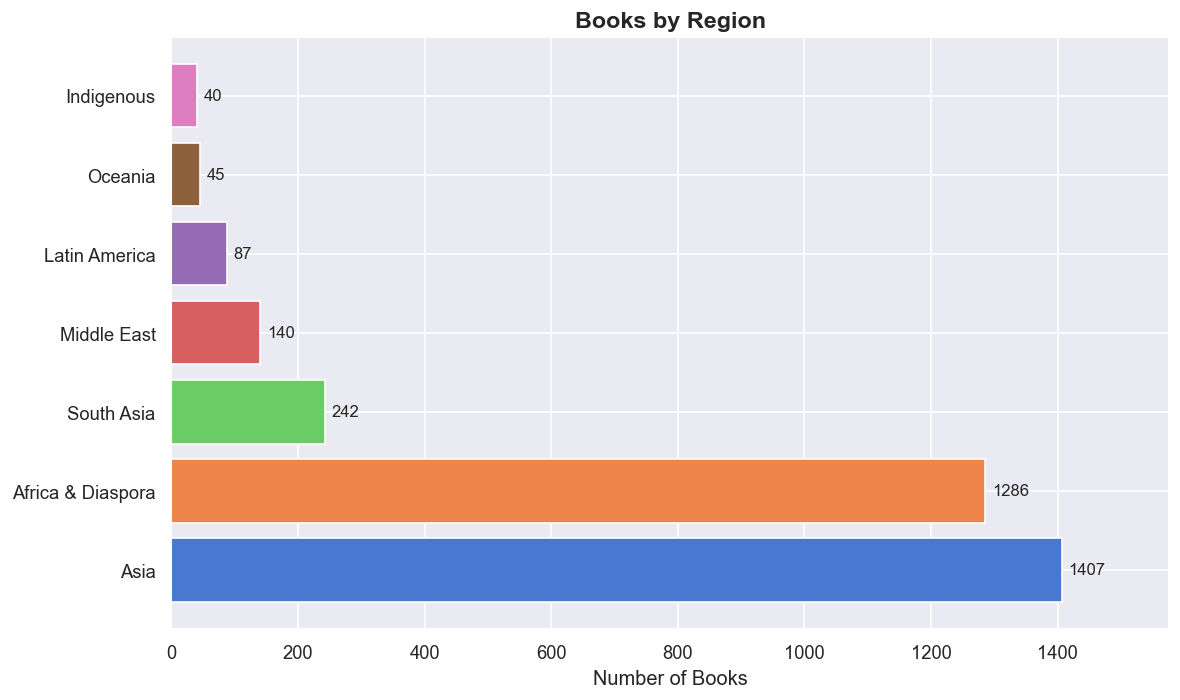

Chart 1 saved


In [4]:
# Chart 1 — Books by region
region_counts = df["region"].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(region_counts.index, region_counts.values,
               color=sns.color_palette("muted", len(region_counts)))
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("Number of Books")
ax.set_title("Books by Region", fontsize=14, fontweight="bold")
ax.set_xlim(0, region_counts.max() * 1.12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "01_books_by_region.png")
plt.show()
print("Chart 1 saved")

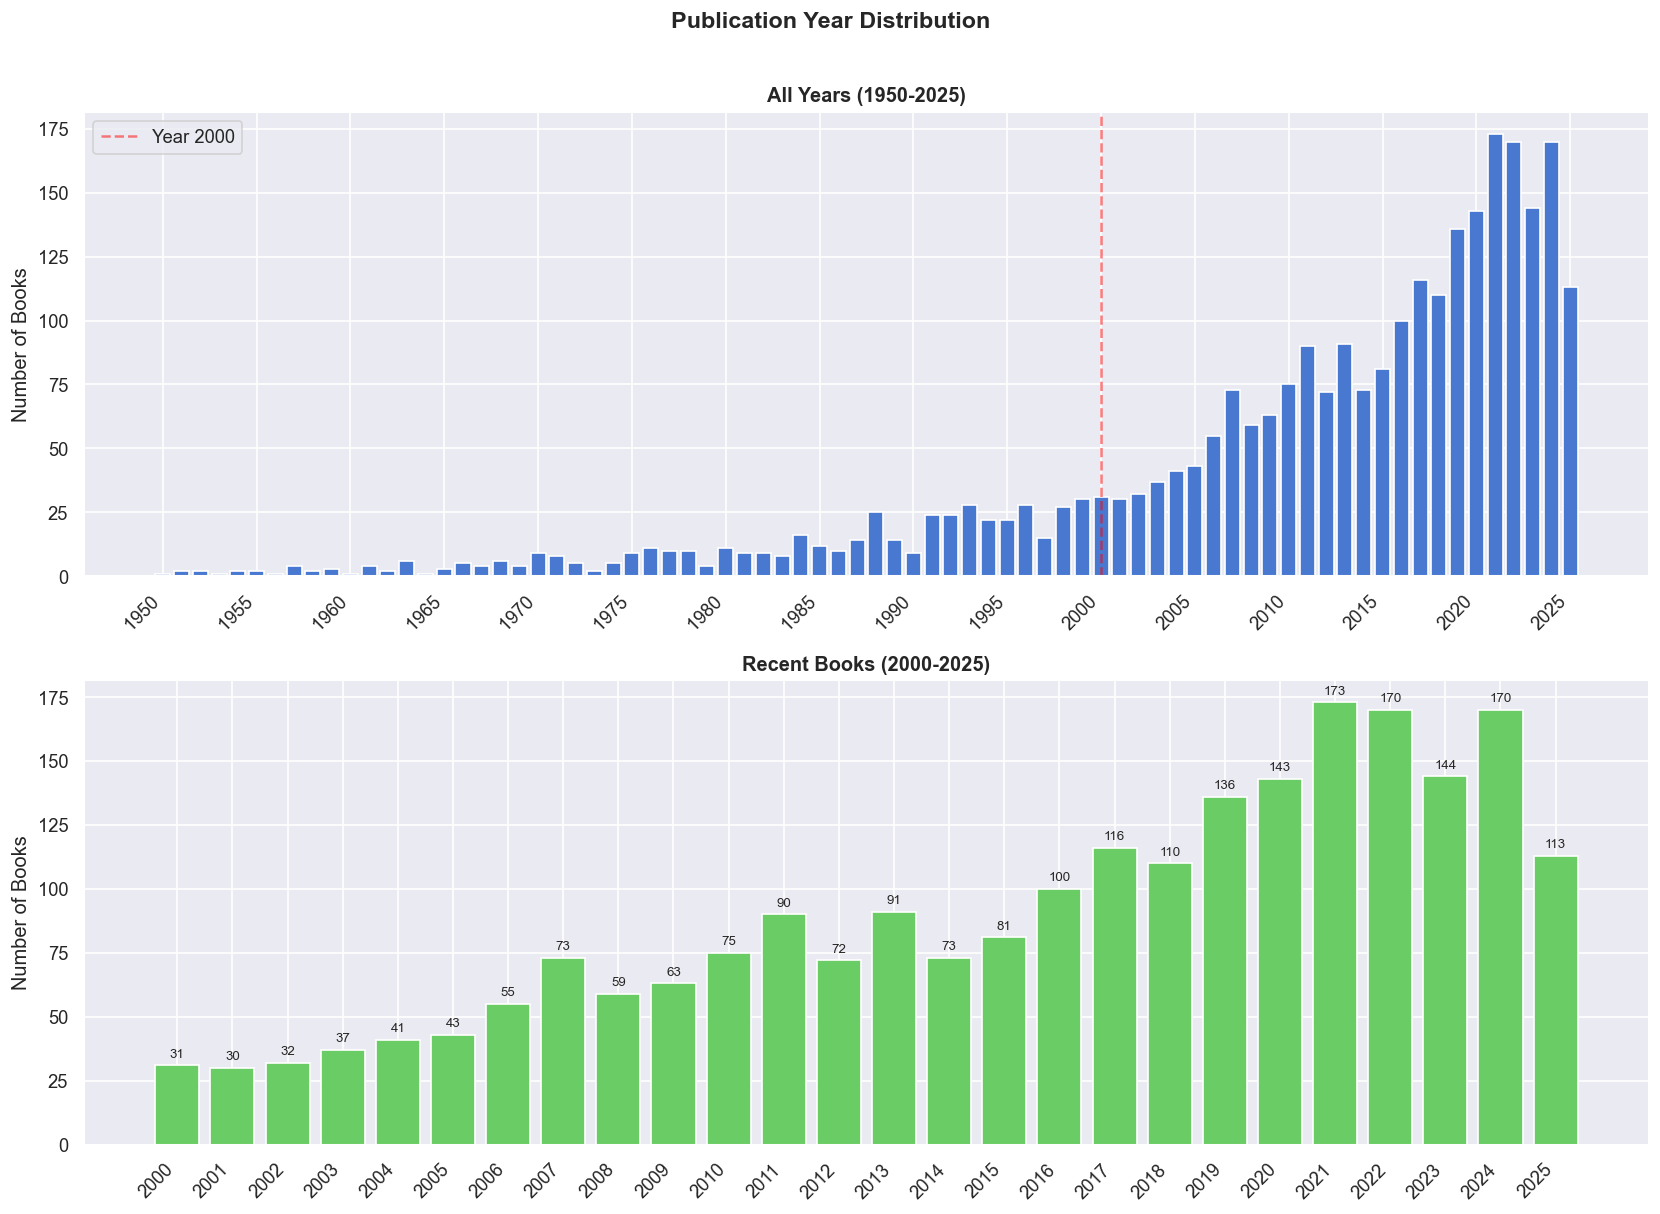

Chart 2 saved


In [5]:
# Chart 2 — Publication years
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
year_all = df[(df["year_published"] >= 1950) & (df["year_published"] <= 2025)]
counts_all = year_all["year_published"].value_counts().sort_index()
ax1.bar(counts_all.index, counts_all.values, color=sns.color_palette("muted")[0], edgecolor="white", width=0.8)
ax1.axvline(x=2000, color="red", linestyle="--", alpha=0.5, label="Year 2000")
ax1.set_xticks(range(1950, 2026, 5))
ax1.set_xticklabels(range(1950, 2026, 5), rotation=45, ha="right")
ax1.set_ylabel("Number of Books")
ax1.set_title("All Years (1950-2025)", fontsize=12, fontweight="bold")
ax1.legend()
year_recent = df[(df["year_published"] >= 2000) & (df["year_published"] <= 2025)]
counts_recent = year_recent["year_published"].value_counts().sort_index()
counts_recent.index = counts_recent.index.astype(int)
bars = ax2.bar(counts_recent.index, counts_recent.values, color=sns.color_palette("muted")[2], edgecolor="white", width=0.8)
ax2.bar_label(bars, padding=3, fontsize=8)
ax2.set_xticks(counts_recent.index)
ax2.set_xticklabels(counts_recent.index.astype(int), rotation=45, ha="right")
ax2.set_ylabel("Number of Books")
ax2.set_title("Recent Books (2000-2025)", fontsize=12, fontweight="bold")
fig.suptitle("Publication Year Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_publication_years.png", bbox_inches="tight")
plt.show()
print("Chart 2 saved")

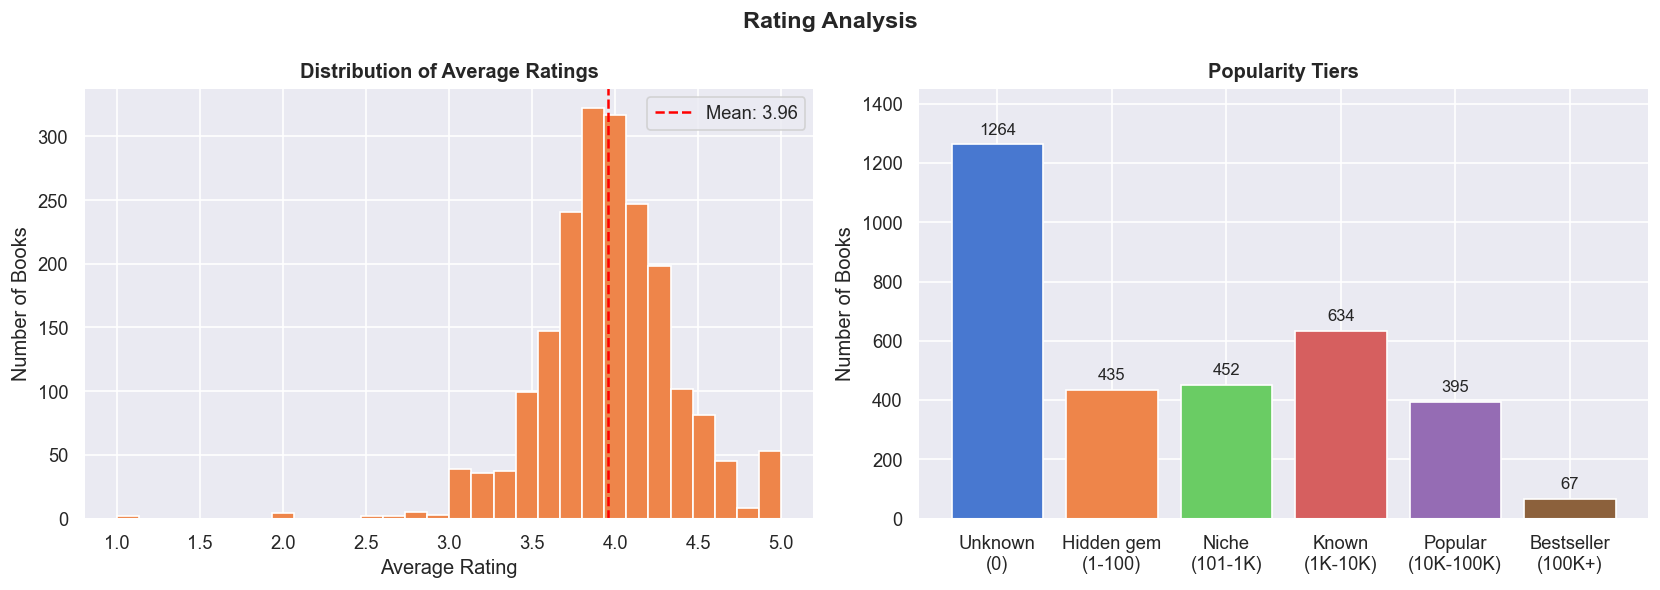

Chart 3 saved


In [6]:
# Chart 3 — Ratings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
rated = df[df["avg_rating"] > 0].copy()
ax1.hist(rated["avg_rating"], bins=30, color=sns.color_palette("muted")[1], edgecolor="white")
ax1.set_xlabel("Average Rating")
ax1.set_ylabel("Number of Books")
ax1.set_title("Distribution of Average Ratings", fontsize=12, fontweight="bold")
ax1.axvline(rated["avg_rating"].mean(), color="red", linestyle="--",
            label=f"Mean: {rated['avg_rating'].mean():.2f}")
ax1.legend()
has_ratings = df[df["num_ratings"] > 0].copy()
tiers = {
    "Unknown\n(0)": (df["num_ratings"] == 0).sum(),
    "Hidden gem\n(1-100)": ((has_ratings["num_ratings"] >= 1) & (has_ratings["num_ratings"] <= 100)).sum(),
    "Niche\n(101-1K)": ((has_ratings["num_ratings"] > 100) & (has_ratings["num_ratings"] <= 1000)).sum(),
    "Known\n(1K-10K)": ((has_ratings["num_ratings"] > 1000) & (has_ratings["num_ratings"] <= 10000)).sum(),
    "Popular\n(10K-100K)": ((has_ratings["num_ratings"] > 10000) & (has_ratings["num_ratings"] <= 100000)).sum(),
    "Bestseller\n(100K+)": (has_ratings["num_ratings"] > 100000).sum(),
}
bars = ax2.bar(tiers.keys(), tiers.values(), color=sns.color_palette("muted", len(tiers)), edgecolor="white")
ax2.bar_label(bars, padding=4, fontsize=10)
ax2.set_ylabel("Number of Books")
ax2.set_title("Popularity Tiers", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(tiers.values()) * 1.15)
plt.suptitle("Rating Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "03_ratings.png", bbox_inches="tight")
plt.show()
print("Chart 3 saved")

In [7]:
# Charts 4-8 — run from 04_eda_fantasy.py or add cells here following the same pattern
print("See 04_eda_fantasy.py for charts 4-8 implementations")

See 04_eda_fantasy.py for charts 4-8 implementations


## 3. TF-IDF Setup

Run this cell before charts 9-13.

In [24]:
SYNONYM_MAP = {
    "mage": "magic_user", "sorcerer": "magic_user", "wizard": "magic_user",
    "enchanter": "magic_user", "warlock": "magic_user", "magician": "magic_user",
    "witch": "magic_user", "shaman": "magic_user", "spellcaster": "magic_user",
    "sorcery": "magic", "witchcraft": "magic", "enchantment": "magic",
    "spells": "magic", "arcane": "magic", "mystical": "magic",
    "fighter": "warrior", "soldier": "warrior", "knight": "warrior",
    "samurai": "warrior", "hunter": "warrior", "assassin": "warrior",
    "mercenary": "warrior",
    "queen": "royalty", "king": "royalty", "emperor": "royalty",
    "empress": "royalty", "prince": "royalty", "princess": "royalty",
    "ruler": "royalty", "throne": "royalty",
    "demon": "spirit", "god": "spirit", "goddess": "spirit",
    "deity": "spirit", "ancestor": "spirit", "ghost": "spirit",
    "orisha": "spirit",
    "quest": "journey", "adventure": "journey", "expedition": "journey",
    "travel": "journey", "mission": "journey", "voyage": "journey",
}

custom_stop = list(ENGLISH_STOP_WORDS) + [
    "book", "novel", "fiction", "author", "story", "stories", "classics",
    "series", "readers", "bestselling", "award", "pages", "work",
    "known", "written", "writing", "writer", "read", "reading", "writers",
    "works", "collection", "life", "young", "people", "new", "world", "time", "old",
    "man", "woman", "girl", "boy", "father", "mother", "son", "daughter", "human", 
    "way", "day", "year", "years", "save", "help", "come", "comes", "find", "finds",
    "take", "takes", "make", "makes", "begin", "begins", "like", "stop", "wants", 
    "debut", "epic", "things", "left", "age", "knows", "long", "set", "just", "best",
    "na", "tan", "scott", "morgan", "american", "city", "2003", "great", "eli", "inez",
    "eva", "rick", "riordan", "rick riordan", "nina", "1920s", "sara", "ago", "house",
]

def normalize_synonyms(text):
    words = str(text).lower().split()
    return " ".join(SYNONYM_MAP.get(w, w) for w in words)

desc_mask = df["description"].apply(
    lambda x: bool(str(x).strip()) and str(x).strip() != "nan" and
    "A work of fantasy fiction involving" not in str(x)
)
df_tfidf = df[desc_mask].copy().reset_index(drop=True)
df_tfidf["description"] = df_tfidf["description"].apply(normalize_synonyms)
df_tfidf["region"] = df_tfidf["source_tag"].map(REGION_MAP).fillna("Other")

vectorizer = TfidfVectorizer(max_features=5000, stop_words=custom_stop, min_df=3, ngram_range=(1, 2))
tfidf_matrix  = vectorizer.fit_transform(df_tfidf["description"])
feature_names = np.array(vectorizer.get_feature_names_out())
mean_scores   = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

print(f"Books with real descriptions: {len(df_tfidf):,}")
print(f"Vocabulary size: {len(feature_names):,} terms")
print("TF-IDF matrix ready")

Books with real descriptions: 2,802
Vocabulary size: 5,000 terms
TF-IDF matrix ready


## 4. TF-IDF Charts (9-13)

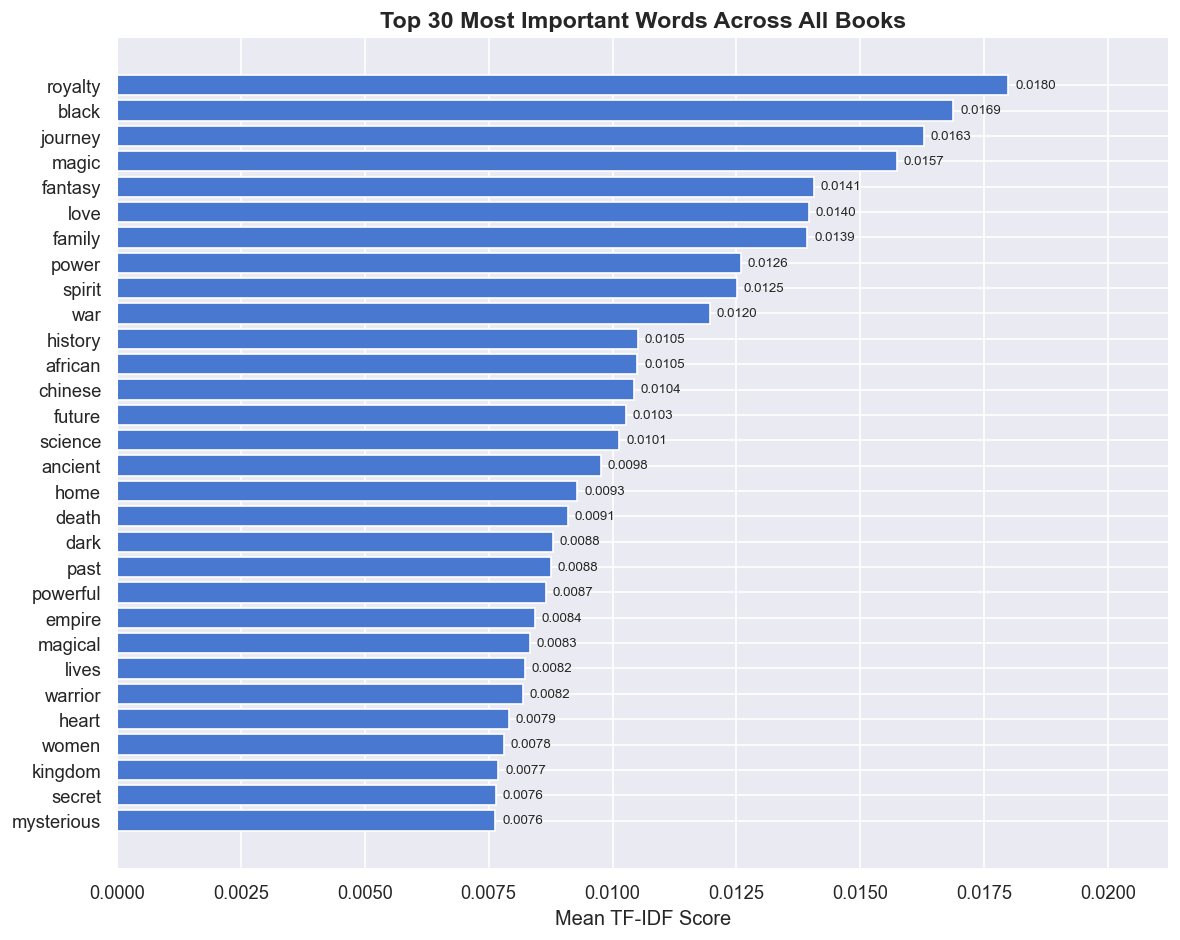

Chart 9 saved


In [25]:
# Chart 9 — Top 30 words
top_idx    = mean_scores.argsort()[-30:][::-1]
top_words  = feature_names[top_idx]
top_scores = mean_scores[top_idx]
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_words[::-1], top_scores[::-1], color=sns.color_palette("muted")[0], edgecolor="white")
ax.set_xlabel("Mean TF-IDF Score")
ax.set_title("Top 30 Most Important Words Across All Books", fontsize=14, fontweight="bold")
ax.bar_label(bars, labels=[f"{v:.4f}" for v in top_scores[::-1]], padding=4, fontsize=8)
ax.set_xlim(0, top_scores.max() * 1.18)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "09_top_tfidf_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 9 saved")

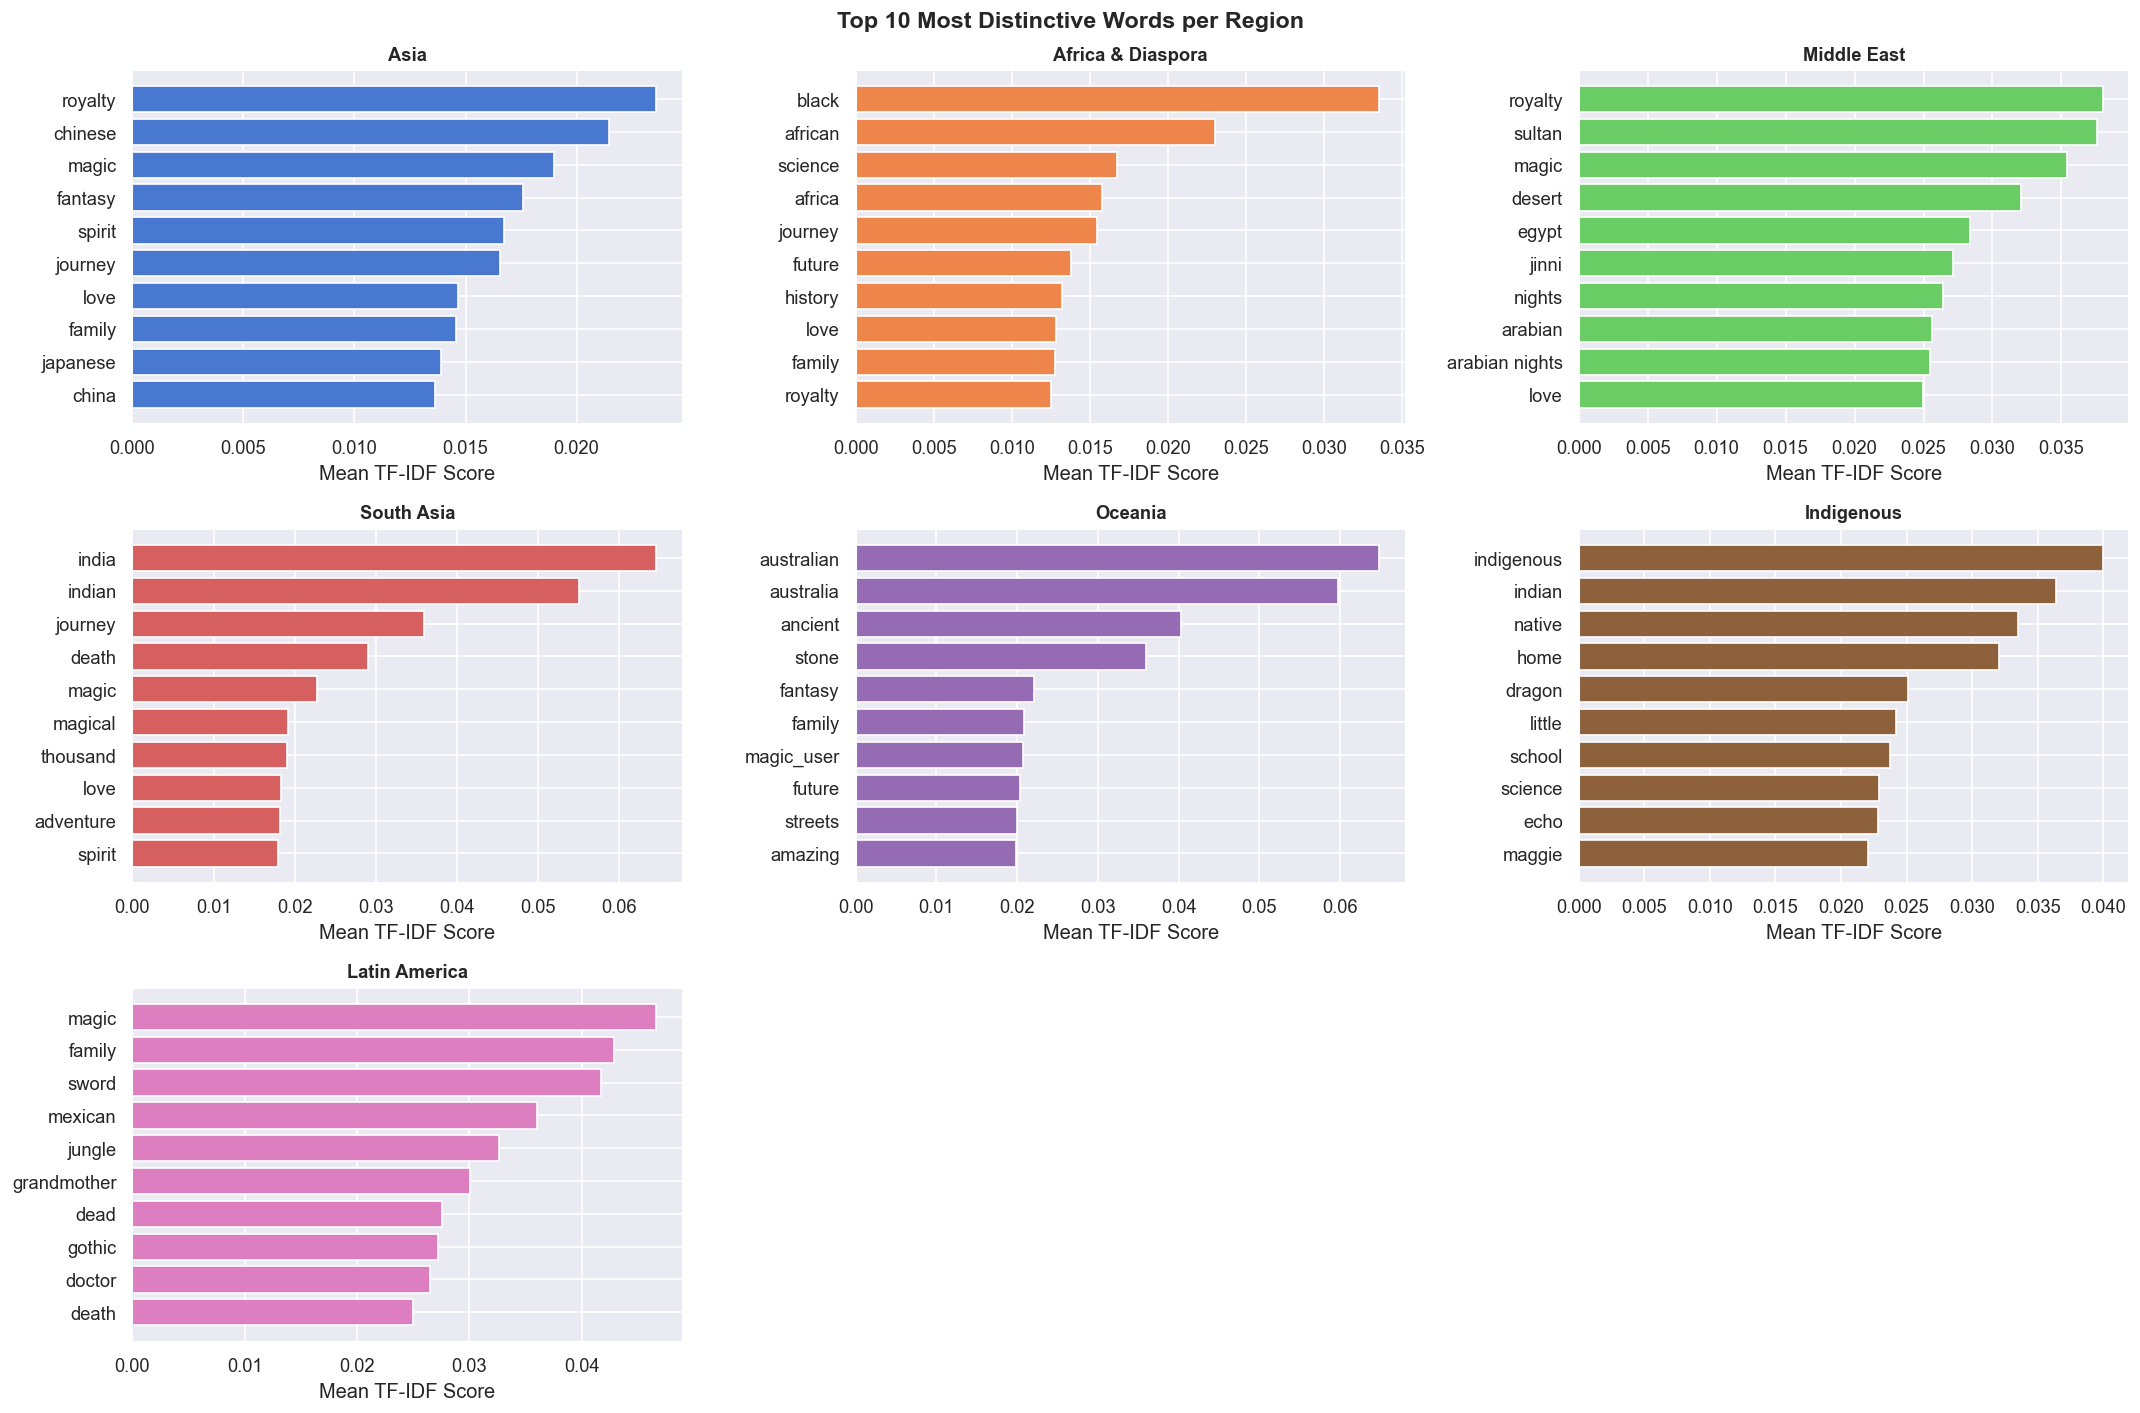

Chart 10 saved


In [26]:
# Chart 10 — Top 10 words per region
regions = [r for r in df_tfidf["region"].value_counts().index if r != "Other"]
n_cols  = 3
n_rows  = -(-len(regions) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
for i, region in enumerate(regions):
    mask = df_tfidf["region"] == region
    indices = np.where(mask)[0]
    region_matrix = tfidf_matrix[indices]
    region_scores = np.asarray(region_matrix.mean(axis=0)).flatten()
    top10_idx = region_scores.argsort()[-10:][::-1]
    axes[i].barh(feature_names[top10_idx][::-1], region_scores[top10_idx][::-1],
                 color=sns.color_palette("muted")[i % 8], edgecolor="white")
    axes[i].set_title(region, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Mean TF-IDF Score")
for j in range(len(regions), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Top 10 Most Distinctive Words per Region", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "10_tfidf_words_per_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 10 saved")

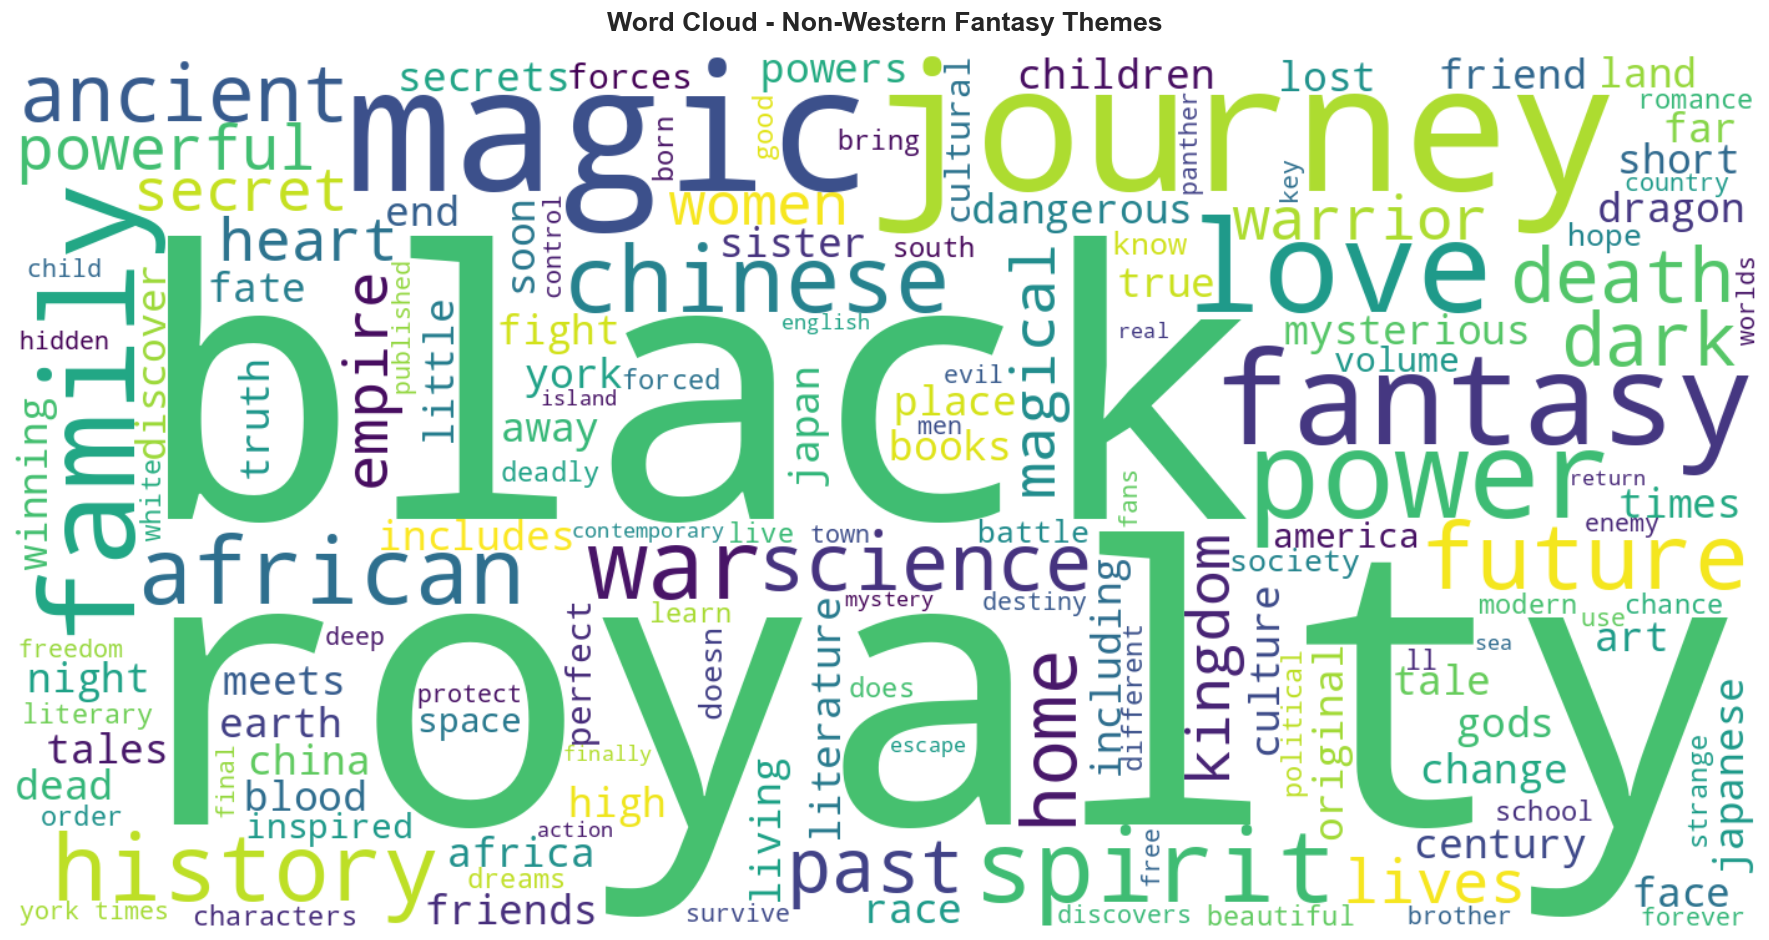

Chart 11 saved


In [27]:
# Chart 11 — Word cloud
word_scores = dict(zip(feature_names, mean_scores))
wc = WordCloud(width=1400, height=700, background_color="white",
               colormap="viridis", max_words=150, prefer_horizontal=0.85)
wc.generate_from_frequencies(word_scores)
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud - Non-Western Fantasy Themes", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "11_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 11 saved")

In [28]:
# Chart 12 — UMAP + HDBSCAN (takes ~1 min)
print("Running UMAP...")
reducer   = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.02, metric="cosine", random_state=42)
embedding = reducer.fit_transform(tfidf_matrix)
print("Running HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=5, metric="euclidean")
labels    = clusterer.fit_predict(embedding)
df_tfidf["cluster"] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Found {n_clusters} clusters, {(labels == -1).sum()} noise points")
for cid in sorted(set(labels)):
    if cid == -1: continue
    mask = df_tfidf["cluster"] == cid
    print(f"  Cluster {cid} ({mask.sum()} books): {df_tfidf[mask]['region'].value_counts().head(2).to_dict()}")

Running UMAP...


c:\Users\Ready2Use\Documents\my-folder\Ironhack-week10\Book-recommendations\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN...
Found 3 clusters, 65 noise points
  Cluster 0 (27 books): {'Asia': 13, 'Africa & Diaspora': 12}
  Cluster 1 (50 books): {'Africa & Diaspora': 49, 'Asia': 1}
  Cluster 2 (2660 books): {'Asia': 1258, 'Africa & Diaspora': 1210}


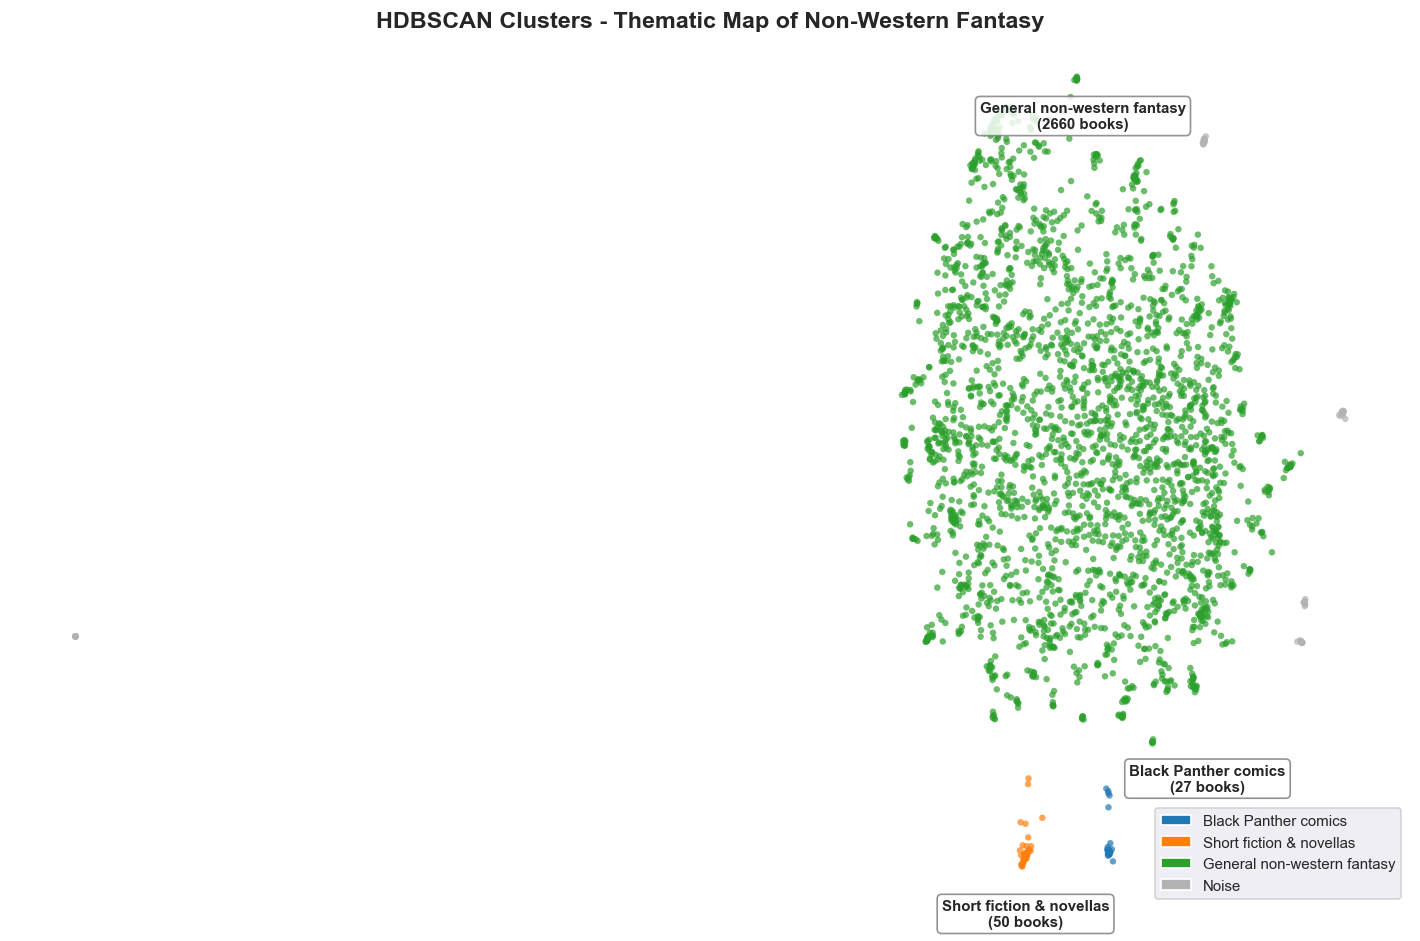

Chart 12a saved


In [39]:
# Chart 12a — HDBSCAN clusters
cluster_labels = {
    0: "Black Panther comics",
    1: "Short fiction & novellas",
    2: "General non-western fantasy",
}
label_offsets = {0: (1.8, 0.5), 1: (0, -0.5), 2: (0, 2.5)}
palette = sns.color_palette("tab10", max(n_clusters, 1))
colors  = [palette[l % 10] if l >= 0 else (0.7, 0.7, 0.7) for l in labels]
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=15, alpha=0.7, linewidths=0)
for cid in range(n_clusters):
    mask   = labels == cid
    cx, cy = embedding[mask, 0].mean(), embedding[mask, 1].mean()
    ox, oy = label_offsets.get(cid, (0, 1.5))
    ax.text(cx + ox, cy + oy,
            f"{cluster_labels.get(cid, f'Cluster {cid}')}\n({mask.sum()} books)",
            fontsize=9, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85, ec="gray"))
legend_elements = [mpatches.Patch(facecolor=palette[i], label=cluster_labels.get(i, f"Cluster {i}"))
                   for i in range(n_clusters)] + [mpatches.Patch(facecolor=(0.7, 0.7, 0.7), label="Noise")]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.8)
ax.set_title("HDBSCAN Clusters - Thematic Map of Non-Western Fantasy", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "12a_hdbscan_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 12a saved")

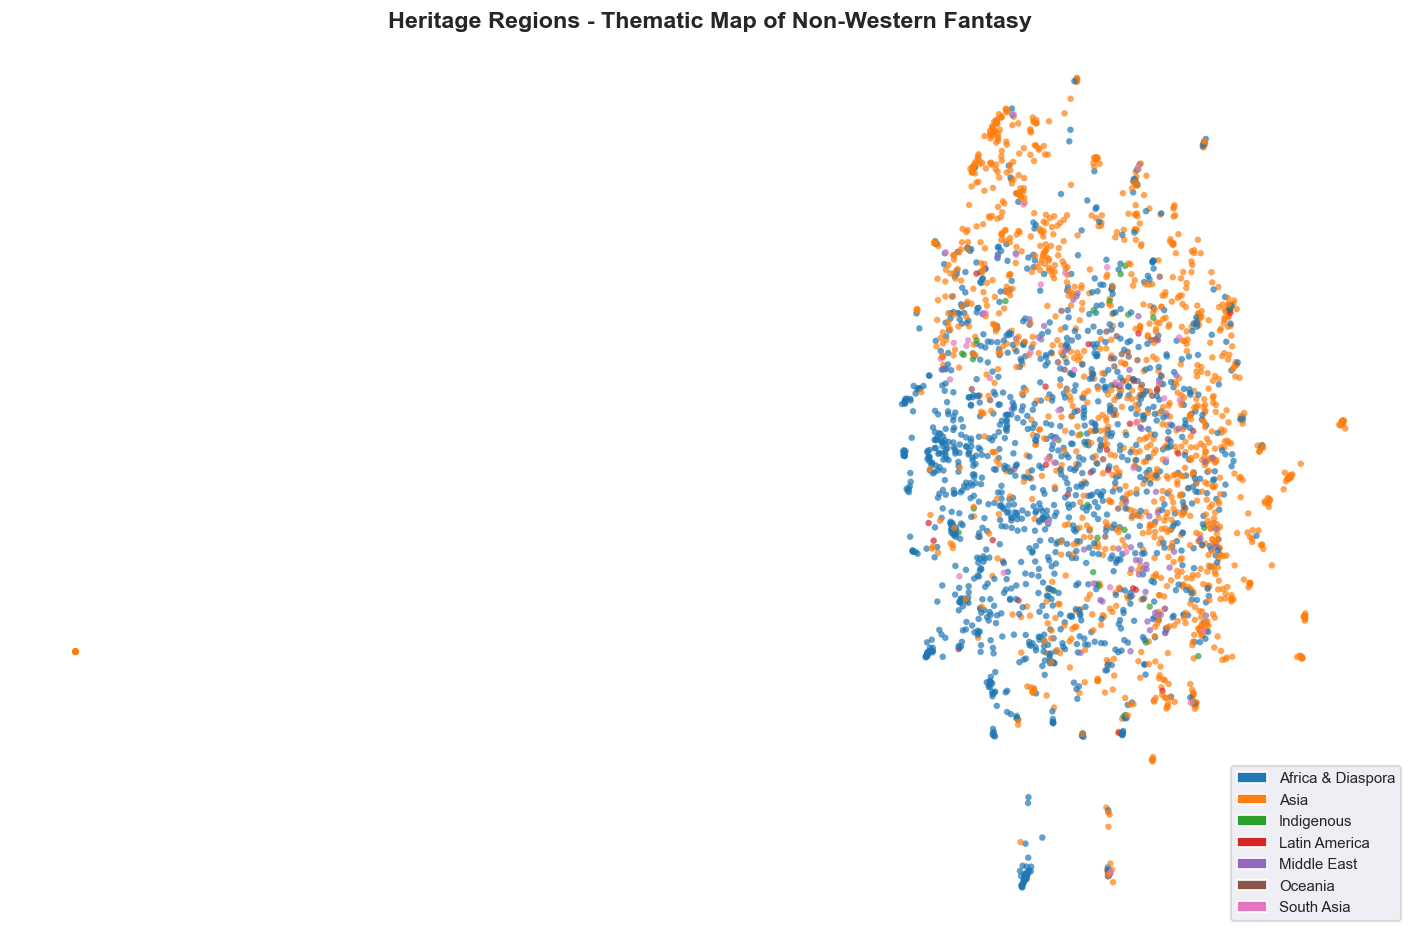

Chart 12b saved


In [40]:
# Chart 12b — Heritage regions
unique_regions = sorted(set(df_tfidf["region"].tolist()))
region_palette = dict(zip(unique_regions, sns.color_palette("tab10", len(unique_regions))))
region_colors  = [region_palette[r] for r in df_tfidf["region"].tolist()]
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(embedding[:, 0], embedding[:, 1], c=region_colors, s=15, alpha=0.7, linewidths=0)
legend_elements = [mpatches.Patch(facecolor=region_palette[r], label=r) for r in unique_regions]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.8)
ax.set_title("Heritage Regions - Thematic Map of Non-Western Fantasy", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "12b_heritage_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 12b saved")

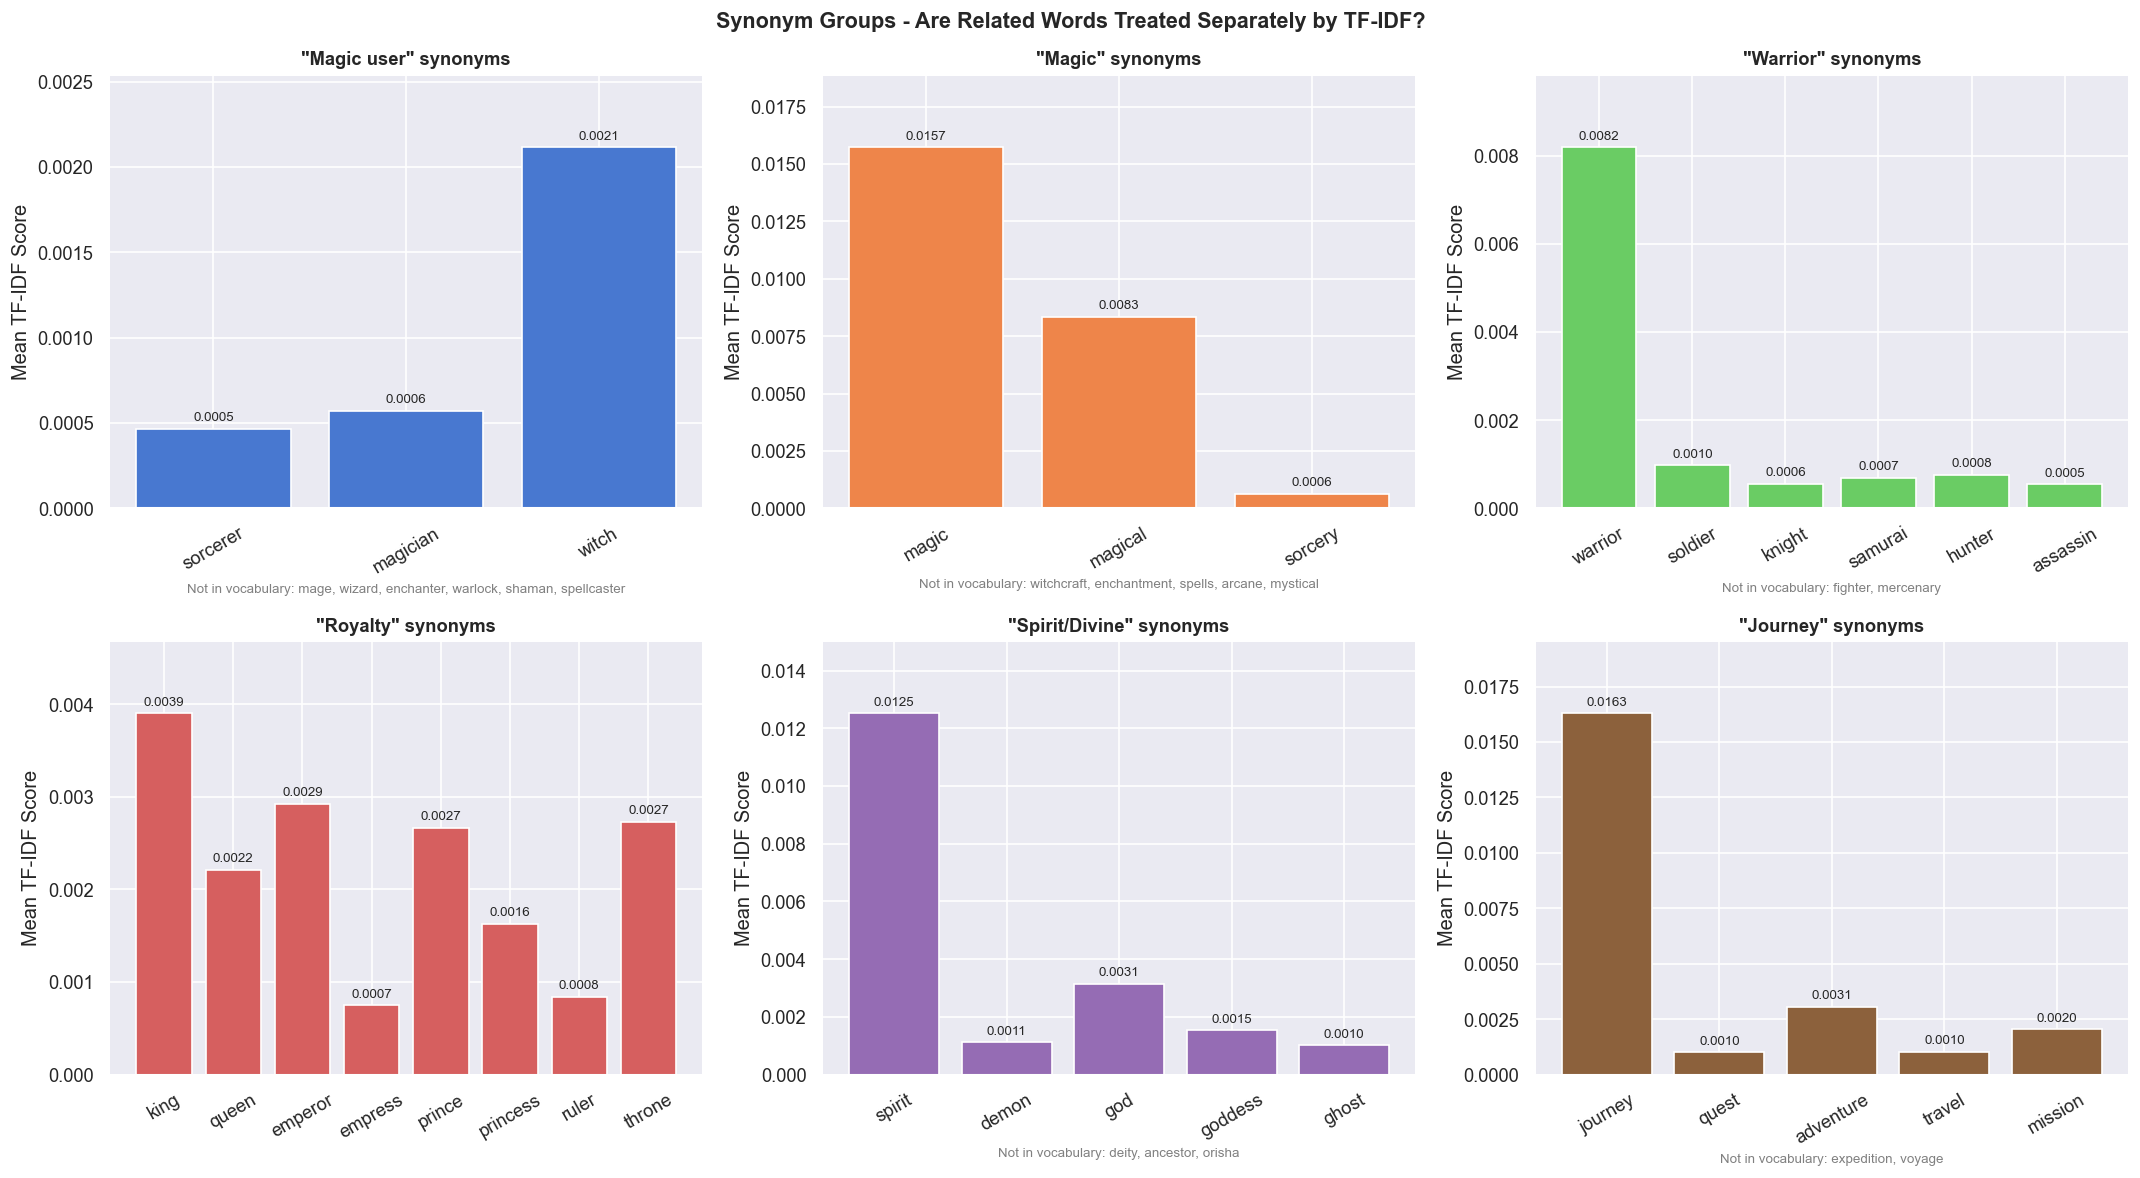

All 13 charts complete!


In [41]:
# Chart 13 — Synonym groups
SYNONYM_GROUPS = {
    "Magic user":    ["mage", "sorcerer", "wizard", "enchanter", "warlock", "magician", "witch", "shaman", "spellcaster"],
    "Magic":         ["magic", "magical", "sorcery", "witchcraft", "enchantment", "spells", "arcane", "mystical"],
    "Warrior":       ["warrior", "fighter", "soldier", "knight", "samurai", "hunter", "assassin", "mercenary"],
    "Royalty":       ["king", "queen", "emperor", "empress", "prince", "princess", "ruler", "throne"],
    "Spirit/Divine": ["spirit", "demon", "god", "goddess", "deity", "ancestor", "ghost", "orisha"],
    "Journey":       ["journey", "quest", "adventure", "expedition", "travel", "mission", "voyage"],
}
vocab_set = set(feature_names)
word_score_dict = dict(zip(feature_names, mean_scores))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (group_name, synonyms) in enumerate(SYNONYM_GROUPS.items()):
    present = [w for w in synonyms if w in vocab_set]
    absent  = [w for w in synonyms if w not in vocab_set]
    scores  = [word_score_dict[w] for w in present]
    bars    = axes[i].bar(present, scores, color=[sns.color_palette("muted")[i % 8]] * len(present), edgecolor="white")
    axes[i].bar_label(bars, labels=[f"{v:.4f}" for v in scores], padding=3, fontsize=8)
    axes[i].set_title(f'"{ group_name}" synonyms', fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Mean TF-IDF Score")
    axes[i].tick_params(axis="x", rotation=30)
    if scores: axes[i].set_ylim(0, max(scores) * 1.2)
    if absent: axes[i].set_xlabel(f"Not in vocabulary: {', '.join(absent)}", fontsize=8, color="gray")
plt.suptitle("Synonym Groups - Are Related Words Treated Separately by TF-IDF?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "13_synonym_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("All 13 charts complete!")

## Conclusions

### Dataset
- Asia and Africa & Diaspora dominate the collection
- Publication volume has grown sharply since 2018, reflecting the broader OwnVoices movement
- ~75% of books have real descriptions, sufficient for TF-IDF modeling

### TF-IDF findings
- Top vocabulary per region is highly distinctive (djinn/sultan for Middle East, australia/aboriginal for Oceania)
- HDBSCAN found 4 coherent clusters: Black Panther comics, Chinese web novels, short fiction, and a large general group
- The synonym analysis confirms TF-IDF treats witch/mage/sorcerer as separate signals — addressed via synonym normalization in Notebook 05

**Next:** Notebook 05 builds the TF-IDF recommender using these insights.